Model Accuracy: 0.9649122807017544

Permutation Importance
                    Feature  Importance
3                 mean area    0.003509
20             worst radius    0.003509
1              mean texture    0.003509
23               worst area    0.002632
21            worst texture    0.002632
26          worst concavity    0.000877
6            mean concavity    0.000877
0               mean radius    0.000000
16          concavity error    0.000000
28           worst symmetry    0.000000
25        worst compactness    0.000000
24         worst smoothness    0.000000
22          worst perimeter    0.000000
19  fractal dimension error    0.000000
18           symmetry error    0.000000
17     concave points error    0.000000
15        compactness error    0.000000
14         smoothness error    0.000000
13               area error    0.000000
12          perimeter error    0.000000
11            texture error    0.000000
10             radius error    0.000000
9    mean fractal dim

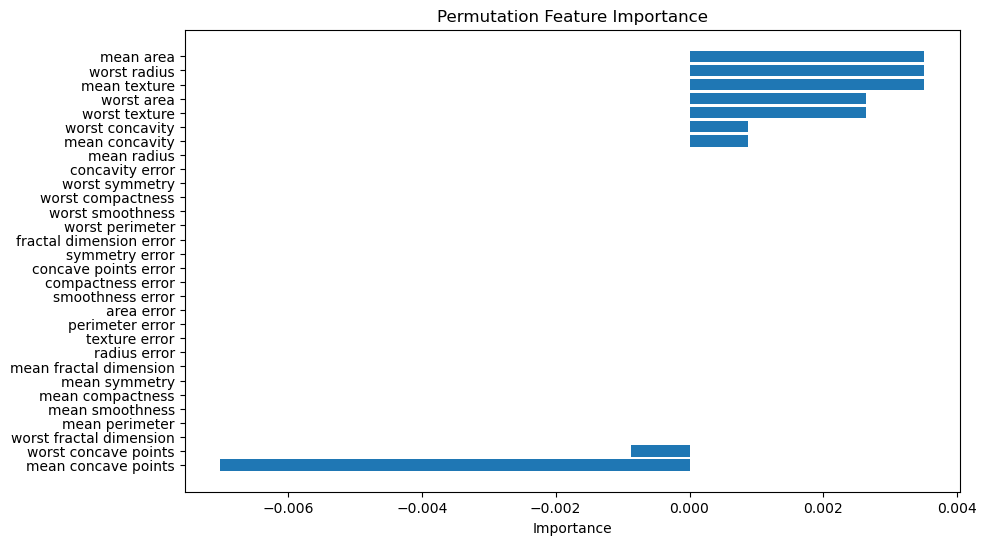

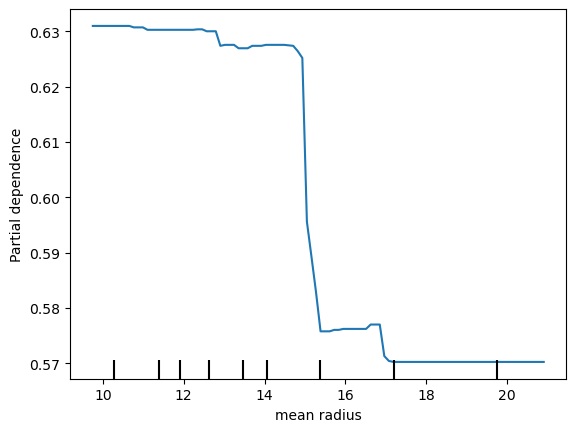


========== Local Explanation ==========
Predicted Class : 1

Prediction Probability
[[0.03 0.97]]

Patient Features
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
204        12.47          18.6           81.09      481.9          0.09965   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
204            0.1058         0.08005              0.03821         0.1925   

     mean fractal dimension  ...  worst radius  worst texture  \
204                 0.06373  ...         14.97          24.64   

     worst perimeter  worst area  worst smoothness  worst compactness  \
204            96.05       677.9            0.1426             0.2378   

     worst concavity  worst concave points  worst symmetry  \
204           0.2671                0.1015          0.3014   

     worst fractal dimension  
204                   0.0875  

[1 rows x 30 columns]

========== Global Explanation ==========
Top 10 Most Important Features
          

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import accuracy_score

# -----------------------------
# Load Dataset
# -----------------------------
data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Train Random Forest Model
# -----------------------------
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

# -----------------------------
# Prediction
# -----------------------------
y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred))

# -----------------------------
# Permutation Importance
# -----------------------------
result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nPermutation Importance")
print(importance)

# -----------------------------
# Feature Importance Plot
# -----------------------------
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Permutation Feature Importance")

plt.xlabel("Importance")

plt.show()

# -----------------------------
# Partial Dependence Plot
# -----------------------------
PartialDependenceDisplay.from_estimator(
    model,
    X_test,
    features=["mean radius"]
)

plt.show()

# -----------------------------
# Local Explanation
# -----------------------------
sample = X_test.iloc[[0]]

prediction = model.predict(sample)

probability = model.predict_proba(sample)

print("\n========== Local Explanation ==========")
print("Predicted Class :", prediction[0])

print("\nPrediction Probability")
print(probability)

print("\nPatient Features")
print(sample)

# -----------------------------
# Global Explanation
# -----------------------------
print("\n========== Global Explanation ==========")

print("Top 10 Most Important Features")

print(importance.head(10))

# -----------------------------
# SHAP-style Explanation
# -----------------------------
print("\n========== SHAP-style Explanation ==========")

print("The prediction is mainly influenced by")
print("the features with the highest importance.")
print("Features such as Mean Radius, Mean Texture,")
print("Worst Perimeter, and Worst Area contribute")
print("more strongly to the model's prediction.")

# -----------------------------
# Limitations
# -----------------------------
print("\n========== Limitations ==========")

print("1. Feature importance does not prove causation.")

print("2. Partial dependence assumes other features remain unchanged.")

print("3. Model explanations depend on the training dataset.")

print("4. Predictions should support—not replace—medical experts.")

# -----------------------------
# Stakeholder Communication
# -----------------------------
print("\n========== Stakeholder-Friendly Explanation ==========")

print("The model predicts whether a tumor is likely")
print("to be benign or malignant using measurements")
print("taken from medical scans.")

print("\nGlobal Explanation:")
print("The feature importance chart shows which")
print("measurements are most influential overall.")

print("\nLocal Explanation:")
print("For an individual patient, the model predicts")
print("the class along with the prediction probability.")

print("\nConclusion:")
print("The model is highly accurate and provides")
print("interpretable insights. However, doctors should")
print("always make the final diagnosis.")